# 

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.io as pio
pio.renderers.defaule = 'colab'

from itables import show

# This stops a few warning messages from showing
pd.options.mode.chained_assignment = None 
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# Machine Learning Packages
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression 

In [18]:
file_location = '/Users/diegocardenas/GroupProject/GroupProjectData101/csv/COVID clinical trials.csv'
DF_Covid = pd.read_csv(file_location,na_filter=False)
DF_Covid.columns

Index(['Rank', 'NCT Number', 'Title', 'Acronym', 'Status', 'Study Results',
       'Conditions', 'Interventions', 'Outcome Measures',
       'Sponsor/Collaborators', 'Gender', 'Age', 'Phases', 'Enrollment',
       'Funded Bys', 'Study Type', 'Study Designs', 'Other IDs', 'Start Date',
       'Primary Completion Date', 'Completion Date', 'First Posted',
       'Results First Posted', 'Last Update Posted', 'Locations',
       'Study Documents', 'URL'],
      dtype='object')

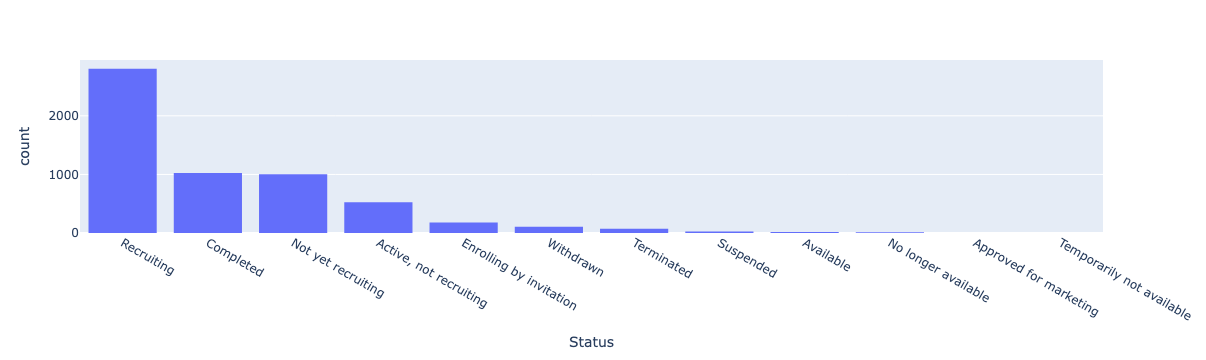

In [3]:
status = DF_Covid
mask = DF_Covid['Status'].value_counts().sort_values(ascending=False)

fig = px.histogram(
    DF_Covid,
    x='Status',
    category_orders={'Status': mask.index} 
)

fig.show()

In [9]:
show(DF_Covid)

Loading ITables v2.5.2 from the internet... (need help?)


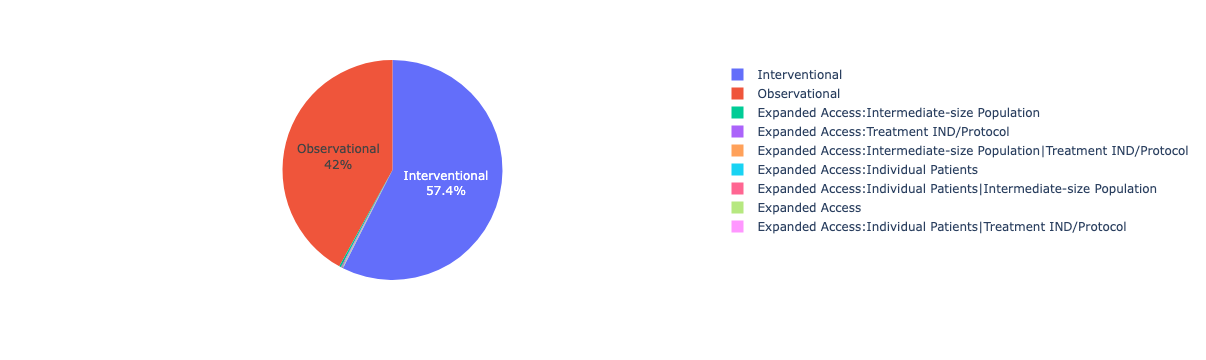

In [17]:
fig = px.pie(DF_Covid, names = 'Study Type')

fig.update_traces(textposition='inside', textinfo='percent+label')

fig.show()

In [23]:
myCol = ['Funded Bys', 'Study Type','Age']

DF = DF_Covid[myCol]

show(DF)

Loading ITables v2.5.2 from the internet... (need help?)


In [25]:
ages = DF['Age'].unique()
show(ages)

Loading ITables v2.5.2 from the internet... (need help?)


In [69]:
def categorize(ages):
    if pd.isna(ages):
        return "Unknown"
    age_clean = ages.replace('\xa0', ' ')
    
    has_child = "Child" in age_clean
    has_adult = "Adult" in age_clean and "Older Adult" not in age_clean
    has_older = "Older Adult" in age_clean

    if has_child and not has_adult and not has_older:
        return "Child Only"
    if has_adult and not has_child and not has_older:
        return "Adult Only"
    if has_older and not has_child and not has_adult:
        return "Older Adult Only"
    if has_child and has_adult and not has_older:
        return "Child + Adult"
    if has_adult and has_older and not has_child:
        return "Adult + Older Adult"
    return "Child + Adult + Older Adult"

DF['Age Category'] = DF['Age'].apply(categorize)

show(DF['Age Category'].value_counts())
show(DF)


Loading ITables v2.5.2 from the internet... (need help?)


Loading ITables v2.5.2 from the internet... (need help?)


In [50]:
show(DF)

Loading ITables v2.5.2 from the internet... (need help?)


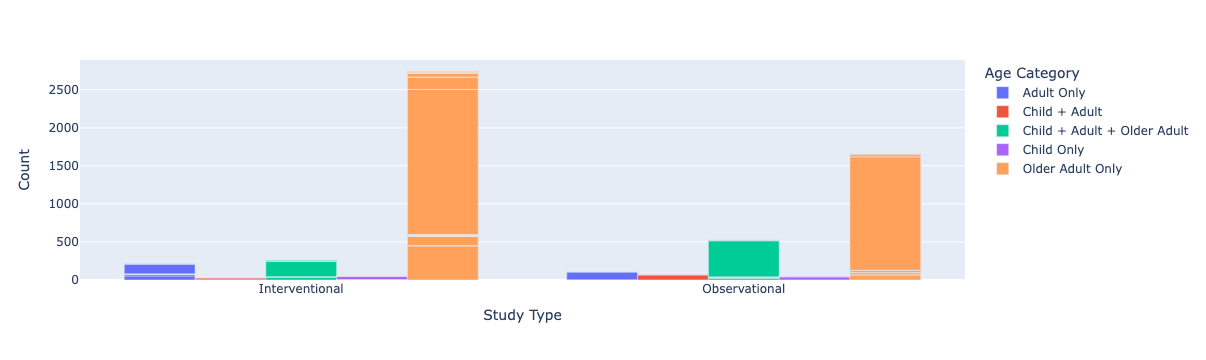

In [53]:
DF_counts = DF.groupby(['Study Type', 'Age Category', 'Funded Bys']).size().reset_index(name='Count')
DF_study = DF_counts[DF_counts['Study Type'].isin(['Interventional', 'Observational'])]

fig = px.bar(
    DF_study,
    x='Study Type',
    y='Count',
    color='Age Category',
    barmode='group'
)

fig.show()

In [55]:
show(DF_Covid)

Loading ITables v2.5.2 from the internet... (need help?)


In [67]:
DF_cond = DF_Covid.rename(columns={'Conditions': 'Condition'})
DF_cond['Condition'] = DF_cond['Condition'].str.strip()  # clean spaces

DF_cond.loc[
    DF_cond['Condition'].str.contains('covid|sars|corona|ncov', case=False, na=False),
    'Condition'
] = 'Covid'


DF_cond['Condition'] = DF_cond['Condition'].apply(lambda x: 'Covid' if x == 'Covid' else 'Other')
show(DF_cond['Condition'].value_counts())
show(DF_cond)

Loading ITables v2.5.2 from the internet... (need help?)


Loading ITables v2.5.2 from the internet... (need help?)


Loading ITables v2.5.2 from the internet... (need help?)


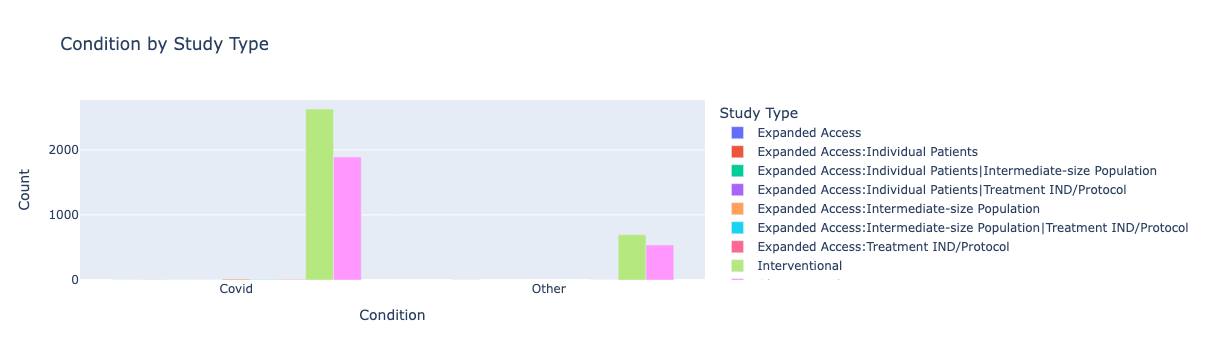

In [66]:
DF_CS = DF_cond.groupby(['Condition', 'Study Type']).size().reset_index(name='Count')
show(DF_CS)

fig = px.bar(
    DF_CS,
    x='Condition',
    y='Count',
    color='Study Type',
    barmode='group',
    title='Condition by Study Type'
)

fig.show()

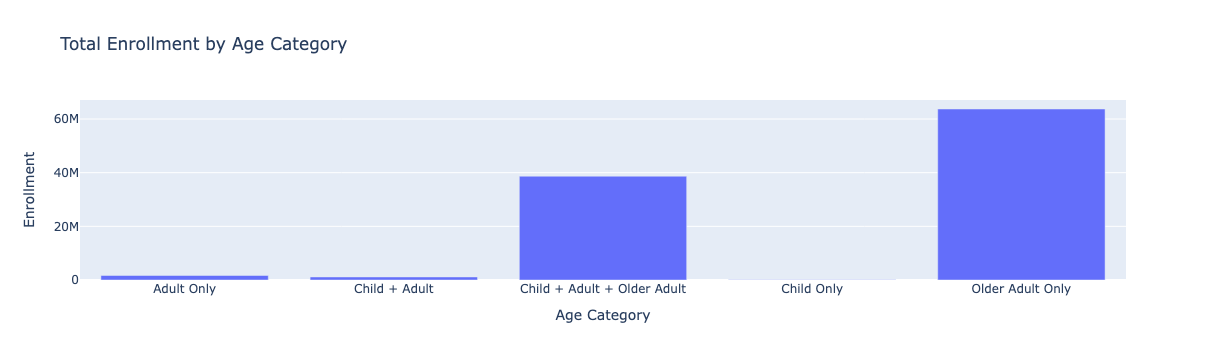

Loading ITables v2.5.2 from the internet... (need help?)


In [85]:
DF = DF_Covid

DF.columns = DF.columns.str.strip()

DF['Enrollment'] = pd.to_numeric(DF['Enrollment'], errors='coerce')

DF['Condition'] = DF['Conditions'].astype(str).str.strip()

DF.loc[
    DF['Condition'].str.contains('covid|sars|corona|ncov', case=False, na=False),
    'Condition'
] = 'Covid'

# Everything else becomes "Other"
DF.loc[DF['Condition'] != 'Covid', 'Condition'] = 'Other'

def categorize(ages):
    if pd.isna(ages):
        return "Unknown"
    age_clean = ages.replace('\xa0', ' ')
    
    has_child = "Child" in age_clean
    has_adult = "Adult" in age_clean and "Older Adult" not in age_clean
    has_older = "Older Adult" in age_clean

    if has_child and not has_adult and not has_older:
        return "Child Only"
    if has_adult and not has_child and not has_older:
        return "Adult Only"
    if has_older and not has_child and not has_adult:
        return "Older Adult Only"
    if has_child and has_adult and not has_older:
        return "Child + Adult"
    if has_adult and has_older and not has_child:
        return "Adult + Older Adult"
    return "Child + Adult + Older Adult"

DF['Age Category'] = DF['Age'].apply(categorize)

df_age_total = DF.groupby('Age Category')['Enrollment'].sum().reset_index()

fig = px.bar(
    df_age_total,
    x='Age Category',
    y='Enrollment',
    title='Total Enrollment by Age Category'
)

fig.show()

show(DF)


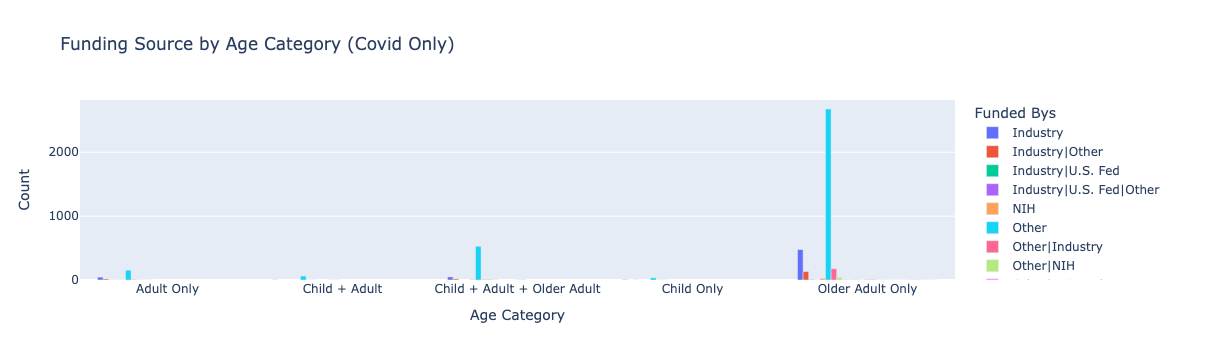

In [95]:
df_group = DF_covid.groupby(['Age Category', 'Funded Bys']).size().reset_index(name='Count')

fig = px.bar(
    df_group,
    x='Age Category',
    y='Count',
    color='Funded Bys',
    barmode='group',
    title='Funding Source by Age Category (Covid Only)'
)

fig.show()

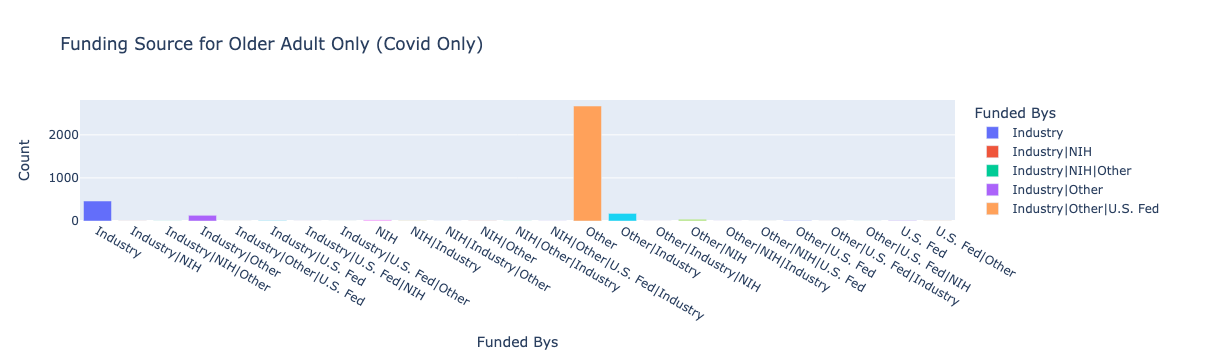

In [97]:

DF_covid = DF[DF['Condition'] == 'Covid']

DF_older = DF_filtered[DF_filtered['Age Category'] == 'Older Adult Only']

df_group = DF_older.groupby(['Age Category', 'Funded Bys']).size().reset_index(name='Count')

fig = px.bar(
    df_group,
    x='Funded Bys',
    y='Count',
    color='Funded Bys',
    title='Funding Source for Older Adult Only (Covid Only)'
)

fig.show()

In [98]:
def simplify_funder(f):
    if pd.isna(f) or f.strip() == "" or f.lower() == "unknown":
        return "Unknown"
    
    f = f.lower()

    # Industry
    if "industry" in f:
        return "Industry"

    # Government (NIH, U.S. Fed, VA, FDA, etc.)
    if "nih" in f or "fed" in f or "federal" in f or "department" in f or "va" in f:
        return "Government"

    # Other organizations (universities, hospitals, networks)
    if "other" in f or "network" in f or "university" in f or "hospital" in f:
        return "Other Non-Profit / Academic"

    # Default fallback
    return "Other Non-Profit / Academic"


# Apply the function
DF['Funding Category'] = DF['Funded Bys'].apply(simplify_funder)

In [99]:
DF['Funding Category'].value_counts()

Funding Category
Other Non-Profit / Academic    4488
Industry                       1094
Government                      201
Name: count, dtype: int64

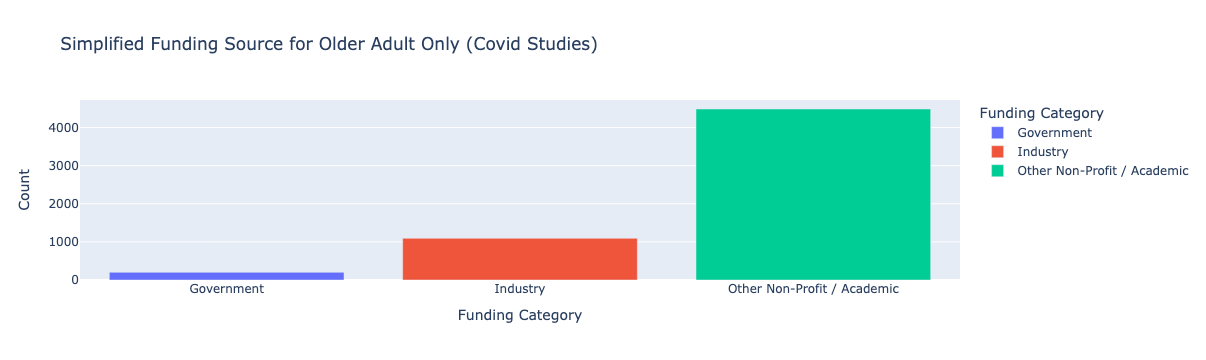

In [102]:
df_group = DF.groupby(['Funding Category']).size().reset_index(name='Count')

fig = px.bar(
    df_group,
    x='Funding Category',
    y='Count',
    color='Funding Category',
    title='Simplified Funding Source for Older Adult Only (Covid Studies)'
)

fig.show()

In [104]:
def simplify_funder(f):
    if pd.isna(f) or f.strip() == "" or f.lower() == "unknown":
        return "Unknown"
    
    f = f.lower()

    # Industry
    if "industry" in f:
        return "Industry"

    # Government (NIH, U.S. Fed, VA, FDA, etc.)
    if "nih" in f or "fed" in f or "federal" in f or "department" in f or "va" in f:
        return "Government"

    # Other organizations (universities, hospitals, networks)
    if "other" in f or "network" in f or "university" in f or "hospital" in f:
        return "Other Non-Profit / Academic"

    # Default fallback
    return "Other Non-Profit / Academic"


# Apply the function
DF['Funding Category'] = DF['Funded Bys'].apply(simplify_funder)


DF_filtered = DF[
    (DF['Condition'] == 'Covid') &
    (DF['Study Type'].isin(['Interventional', 'Observational']))
]

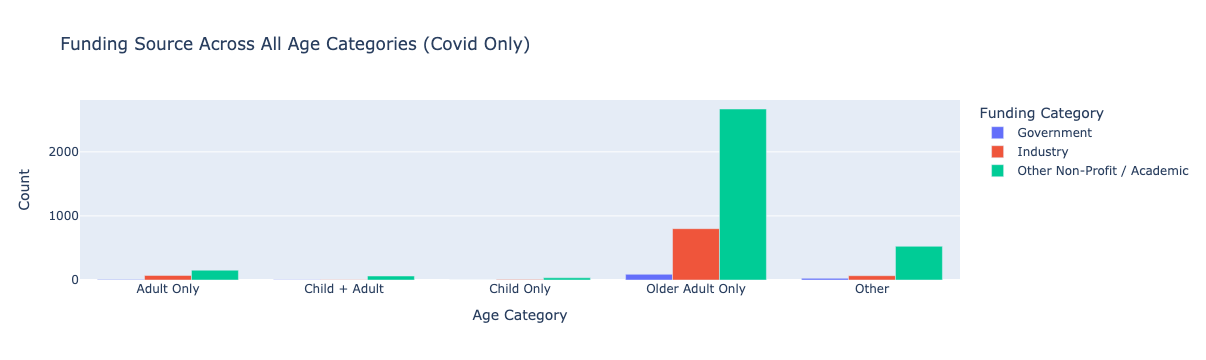

In [109]:
DF = DF_Covid
DF.columns = DF.columns.str.strip()

DF['Enrollment'] = pd.to_numeric(DF['Enrollment'], errors='coerce')

DF['Condition'] = DF['Conditions'].astype(str).str.strip()

DF.loc[
    DF['Condition'].str.contains('covid|sars|corona|ncov', case=False, na=False),
    'Condition'
] = 'Covid'

DF.loc[DF['Condition'] != 'Covid', 'Condition'] = 'Other'

def categorize(age):
    if pd.isna(age):
        return "Unknown"
    
    age_clean = age.replace('\xa0', ' ')
    
    has_child = "Child" in age_clean
    has_adult = "Adult" in age_clean and "Older Adult" not in age_clean
    has_older = "Older Adult" in age_clean

    if has_child and not has_adult and not has_older:
        return "Child Only"
    if has_adult and not has_child and not has_older:
        return "Adult Only"
    if has_older and not has_child and not has_adult:
        return "Older Adult Only"
    if has_child and has_adult and not has_older:
        return "Child + Adult"
    if has_adult and has_older and not has_child:
        return "Adult + Older Adult"
    if has_child and has_adult and has_older:
        return "Child + Adult + Older Adult"
    
    return "Other"

DF['Age Category'] = DF['Age'].apply(categorize)

def simplify_funder(f):
    if pd.isna(f) or f.strip() == "" or f.lower() == "unknown":
        return "Unknown"
    
    f = f.lower()

    if "industry" in f:
        return "Industry"
    if "nih" in f or "fed" in f or "federal" in f or "department" in f or "va" in f:
        return "Government"
    if "other" in f or "network" in f or "university" in f or "hospital" in f:
        return "Other Non-Profit / Academic"
    
    return "Other Non-Profit / Academic"

DF['Funding Category'] = DF['Funded Bys'].apply(simplify_funder)

DF_filtered = DF[
    (DF['Condition'] == 'Covid') &
    (DF['Study Type'].isin(['Interventional', 'Observational']))
]

df_group = DF_filtered.groupby(['Age Category', 'Funding Category']).size().reset_index(name='Count')

fig = px.bar(
    df_group,
    x='Age Category',
    y='Count',
    color='Funding Category',
    barmode='group',
    title='Funding Source Across All Age Categories (Covid Only)'
)

fig.show()